In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Here we show the effect of source size on the interferometric response. 
# The source is modeled as a Gaussian with a given FWHM.
# The interferometer is modeled as a two-element interferometer where we vary the baseline length in one dimension.
# We want to compute the visibility amplitude as a function of baseline length for different source sizes.





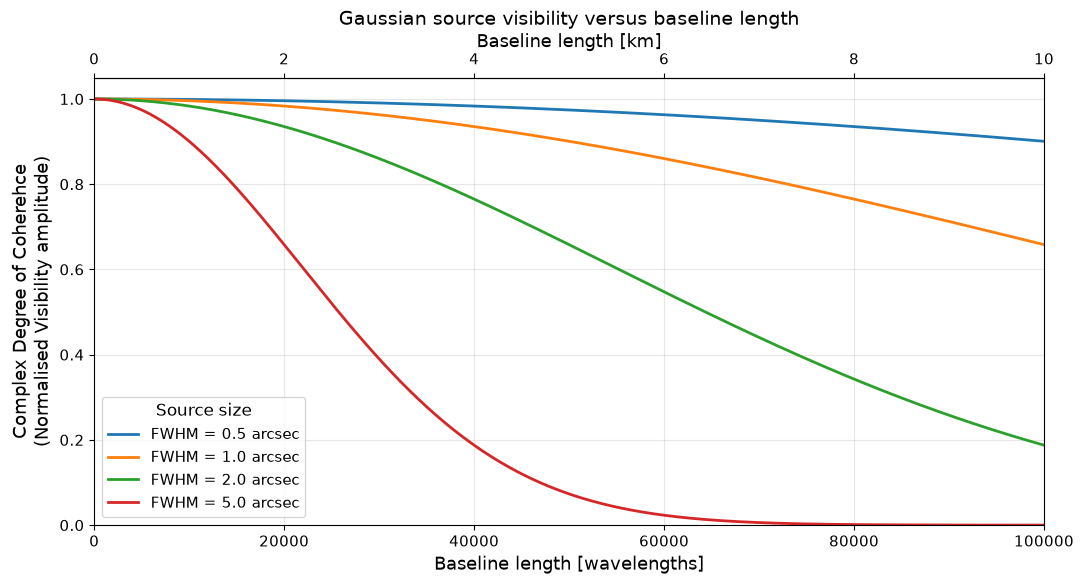

In [5]:
# Simple model for a Gaussian source observed with a two-element interferometer.
# We vary the projected baseline in one dimension and plot the visibility
# amplitude as a function of baseline length for several source sizes.

import numpy as np
import matplotlib.pyplot as plt

# One-dimensional baseline in wavelengths for a much larger interferometer.
# This represents a simple east-west interferometer with a varying separation.
baselines_lambda = np.linspace(0, 100000, 5000)

# Assume a 10 cm observing wavelength: lambda = 0.10 m.
# Convert between wavelengths and physical baseline length in km.
wavelength_m = 0.10
baseline_km = baselines_lambda * wavelength_m / 1000.0

# Source size values in arcseconds. The source brightness distribution is Gaussian.
source_fwhm_arcsec = np.array([0.5, 1.0, 2.0, 5.0])
source_fwhm_rad = source_fwhm_arcsec * (np.pi / 648000.0)  # arcsec -> radians

# For a Gaussian source, the normalized visibility amplitude is
#   V(u) = exp[-(pi * theta_FWHM * u / (2 * sqrt(2 ln 2)))^2]
# where u is the baseline length in wavelengths.
source_sigma_rad = source_fwhm_rad / (2.0 * np.sqrt(2.0 * np.log(2.0)))
visibility = np.exp(-(np.pi * source_sigma_rad[:, None] * baselines_lambda[None, :]) ** 2)

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

fig, ax = plt.subplots(figsize=(11, 6))
for i, fwhm in enumerate(source_fwhm_arcsec):
    ax.plot(
        baselines_lambda,
        visibility[i],
        lw=2,
        label=f"FWHM = {fwhm:.1f} arcsec",
    )

ax.set_xlabel("Baseline length [wavelengths]")
ax.set_ylabel("Complex Degree of Coherehce\n(Normalised Visibility amplitude)")
ax.set_title("Gaussian source visibility versus baseline length")
ax.set_xlim(0, baselines_lambda[-1])
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend(title="Source size")

# Add a second x-axis showing the same baseline length in km.
ax_km = ax.secondary_xaxis(
    "top",
    functions=(
        lambda u: u * wavelength_m / 1000.0,
        lambda x_km: x_km * 1000.0 / wavelength_m,
    ),
)
ax_km.set_xlabel("Baseline length [km]")

plt.tight_layout()
plt.show()
